In [27]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import sys
sys.path.append("..")  # db_config.py lives in the repo root
from db_config import read_sql


query = """WITH monthly AS (
    SELECT t.state_code,
           t2.report_date AS reporting_date,
           ROUND(AVG(CAST(t2.loan_age_months AS FLOAT)), 0) AS average_loan_seasoning,
           ROUND(AVG(TRY_CAST(t2.unpaid_principal_balance AS FLOAT)), 2) AS average_upb,
           SUM(TRY_CAST(t2.unpaid_principal_balance AS FLOAT)) AS total_upb,
           ROUND(AVG(CAST(t.loan_interest_rate AS FLOAT)), 2) AS average_interest_rate,
           ROUND(AVG(TRY_CAST(t.credit_score AS FLOAT)), 0) AS average_credit_score,
           SUM(CASE WHEN t2.months_delinquent = 0 THEN 1 ELSE 0 END) AS current_loans,
           SUM(CASE WHEN t2.months_delinquent <> 0 THEN 1 ELSE 0 END) AS delinquent_loans,
           ROUND(CAST(SUM(CASE WHEN t2.months_delinquent <> 0 THEN 1 ELSE 0 END) AS FLOAT)
                 / COUNT(*) * 100, 2) AS delinquency_pct,
           COUNT(t4.disclosure_sequence_number) AS total_liquidations,
           ROUND(CAST(SUM(CASE WHEN t2.months_delinquent <> 0 AND t3.issuer_group = 'Mega' THEN 1 ELSE 0 END) AS FLOAT) / SUM(CASE WHEN t2.months_delinquent <> 0 THEN 1 ELSE 0 END),4) AS mega_dq_pct
    FROM gnma_static_table t
    JOIN mbs_loans_monthly t2 ON t2.disclosure_sequence_number = t.disclosure_sequence_number
    JOIN issuer_info t3 ON t3.issuer_number = t.issuer_id
    LEFT JOIN mbs_monthly_liquidations t4 ON t4.disclosure_sequence_number = t.disclosure_sequence_number
                                         AND t4.report_date = '2026-08-01'
    WHERE t2.report_date IN ('2026-07-01', '2026-08-01')
    GROUP BY t.state_code, t2.report_date
),
trended AS (
    SELECT *,
           LAG(delinquency_pct) OVER (PARTITION BY state_code ORDER BY reporting_date) AS prior_delinquency_pct
    FROM monthly
)
SELECT *,
       delinquency_pct - prior_delinquency_pct AS delinquency_change_pp,
       CASE
           WHEN prior_delinquency_pct IS NULL         THEN 'New'
           WHEN delinquency_pct > prior_delinquency_pct THEN 'Up'
           WHEN delinquency_pct < prior_delinquency_pct THEN 'Down'
           ELSE 'Flat'
       END AS delinquency_trend
FROM trended
WHERE reporting_date = '2026-08-01'
ORDER BY state_code;
"""

df = read_sql(query)


df['delinquency_pct'] = df['delinquency_pct']/100

print(df.head())

C:\Users\H59045\AppData\Local\Temp\1\ipykernel_31164\3567031102.py:55: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


  state_code reporting_date  average_loan_seasoning  average_upb  \
0         AK     2026-08-01                    74.0    250386.98   
1         AL     2026-08-01                    71.0    160444.75   
2         AR     2026-08-01                    75.0    135726.08   
3         AZ     2026-08-01                    62.0    228765.61   
4         CA     2026-08-01                    70.0    323750.30   

      total_upb  average_interest_rate  average_credit_score  current_loans  \
0  9.615611e+09                   4.11                 714.0          36619   
1  4.492341e+10                   4.63                 692.0         251429   
2  2.101447e+10                   4.66                 691.0         139782   
3  7.871047e+10                   4.46                 699.0         315875   
4  2.586227e+11                   4.20                 701.0         732534   

   delinquent_loans  delinquency_pct  total_liquidations  mega_dq_pct  \
0              1784           0.0465       

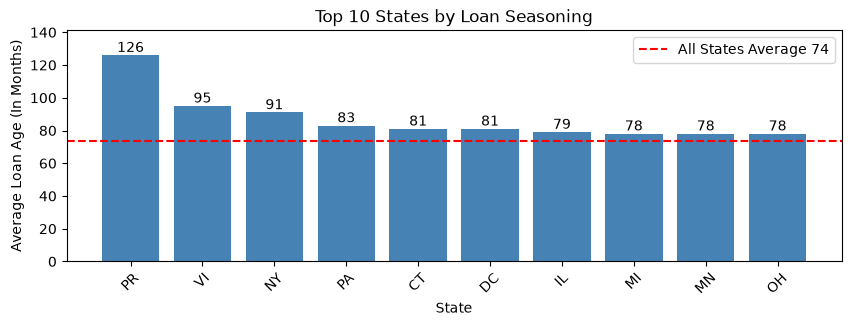

In [28]:
top_states = df.nlargest(10,'average_loan_seasoning')

plt.figure(figsize=(10,3))
bars = plt.bar(top_states['state_code'], top_states['average_loan_seasoning'], color='steelblue',)
plt.bar_label(bars)
plt.title('Top 10 States by Loan Seasoning')
plt.xlabel('State')
plt.ylabel('Average Loan Age (In Months)')
plt.ylim(0, top_states['average_loan_seasoning'].max()*1.12)
plt.xticks(rotation=45)
avg = df['average_loan_seasoning'].mean()
plt.axhline(avg, color='red', linestyle='--', linewidth=1.5, label=f'All States Average {avg:.0f}')
plt.legend()

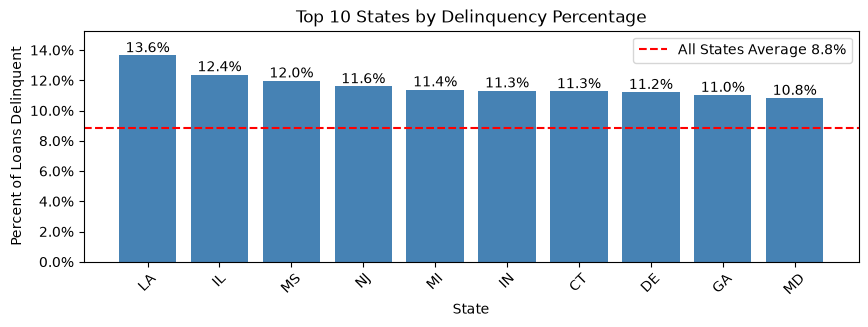

In [29]:
top_states = df.nlargest(10,'delinquency_pct')


plt.figure(figsize=(10,3))
bars = plt.bar(top_states['state_code'], top_states['delinquency_pct'], color='steelblue')
plt.bar_label(bars, fmt=lambda x:f'{x*100:.1f}%')
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=1))
avg = df['delinquency_pct'].mean()
plt.axhline(avg, color='red', linestyle='--', linewidth=1.5,label=f'All States Average {avg:.1%}')
plt.title('Top 10 States by Delinquency Percentage')
plt.xlabel('State')
plt.ylabel('Percent of Loans Delinquent')
plt.ylim(0, top_states['delinquency_pct'].max()*1.12)
plt.xticks(rotation=45)
plt.legend()

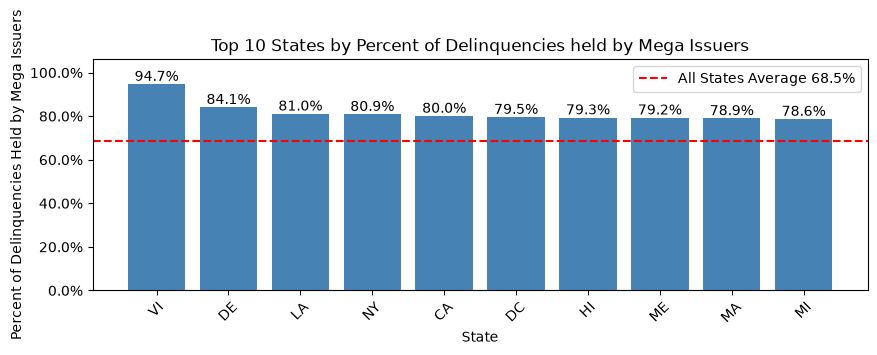

: 

In [ ]:
top_states = df.nlargest(10,'mega_dq_pct')

plt.figure(figsize=(10,3))
bars = plt.bar(top_states['state_code'], top_states['mega_dq_pct'], color='steelblue')
plt.bar_label(bars, fmt=lambda x:f'{x*100:.1f}%')
plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=1))
avg = df['mega_dq_pct'].mean()
plt.axhline(avg, color='red', linestyle='--', linewidth=1.5,label=f'All States Average {avg:.1%}')
plt.title('Top 10 States by Percent of Delinquencies held by Mega Issuers')
plt.xlabel('State')
plt.ylabel('Percent of Delinquencies Held by Mega Issuers')
plt.ylim(0, top_states['mega_dq_pct'].max()*1.12)
plt.xticks(rotation=45)
plt.legend()